# Run infection dynamics with monoclonal killer T cell response

In [1]:
import numpy as np
from matplotlib.cm import get_cmap
import matplotlib.pyplot as plt
import matplotlib as mpl

import multiprocessing as mp
from tqdm import tqdm
from joblib import Parallel, delayed
from scipy import stats
import os
from stoch_sim_model import *
from optimize_nets import *
import seaborn as sns

plt.style.use('custom.mplstyle')
# %config InlineBackend.figure_format = 'retina'
%load_ext line_profiler

In [22]:
avg_sim_time = 2.5/(60*60)

print('full-reg:',(len(psi_2d_nobias)**4)*len(vir_prop_select),
      np.ceil((len(psi_2d_nobias)**4*len(vir_prop_select))/(num_cpu*run_time/avg_sim_time)), int(num_cpu*run_time/avg_sim_time))

print('prim-Nact-Ediv:',len(psi_2d)*len(psi_2d)*len(vir_prop_select), 
      np.ceil((len(psi_2d)*len(psi_2d)*len(vir_prop_select))/(num_cpu*run_time/avg_sim_time)), int(num_cpu*run_time/avg_sim_time))

print('prim-Nact-Ediv-EM:',len(psi_2d)**3*len(vir_prop_select), 
      np.ceil((len(psi_2d)**3*len(vir_prop_select))/(num_cpu*run_time/avg_sim_time)), int(num_cpu*run_time/avg_sim_time))

print('comp_model-Nact-Ediv:',len(psi_2d_comp)*len(psi_2d_comp)*len(vir_prop_select), 
      np.ceil((len(psi_2d_comp)*len(psi_2d_comp)*len(vir_prop_select))/(num_cpu*run_time/avg_sim_time)), int(num_cpu*run_time/avg_sim_time))

print('auto-Nact-Ediv:',len(psi_2d_full)*len(psi_2d_full)*9,
      np.ceil((len(psi_2d_full)*len(psi_2d_full)*9)/(num_cpu*run_time/avg_sim_time)), int(num_cpu*run_time/avg_sim_time))

print('sparse-reg:', len(psi_2d_sparse)*len(vir_prop_select),
      np.ceil(len(psi_2d_sparse)*len(vir_prop_select)/(num_cpu*run_time/avg_sim_time)), int(num_cpu*run_time/avg_sim_time))

full-reg: 2367144300 16439.0 144000
prim-Nact-Ediv: 21067500 147.0 144000
prim-Nact-Ediv-EM: 5582887500 38771.0 144000
comp_model-Nact-Ediv: 4687500 33.0 144000
auto-Nact-Ediv: 3515625 25.0 144000
sparse-reg: 93750000 652.0 144000


### (1) Plot population averaged trajectories

In [3]:
# Set simulation parameters
N_0 = 300
K_IE = (1)*(10**4)
d_I = 125*d_S
b_I = 2.0*(10**(-7))

infection_type = "prim" #"prim", "sec"
vir_model = 'indep_harm' #'indep_harm
mem_reg = psi_max*np.array([-1.0*psi_max/2, -1.0*psi_max/2, -0.0*psi_max/2, -1.0*psi_max/2, -1.0*psi_max/2, -1.0*psi_max/2, 0.0*psi_max/2, -1.0*psi_max/2]) # np.array([-0.5, -0.5, -0.0, -0.5, -0.5, -0.0])

In [4]:
%lprun -T lprof0 -f lin_stoch_sim lin_stoch_sim(N_0 = 10000, b_I = b_I, K_IE = K_IE, d_I = d_I, K_EH = K_EH, NM_regulation = mem_reg[0:4], EM_regulation = mem_reg[4:], activation_regulation = [psi_max/2, psi_max/2, 0, 0], expansion_regulation = [psi_max/2, psi_max/2, 0, 0])


*** Profile printout saved to text file 'lprof0'. 


Timer unit: 1e-09 s

Total time: 7.01316 s
File: /mmfs1/home/oukogu/infoimmune/stoch_sim_model.py
Function: lin_stoch_sim at line 121

Line #      Hits         Time  Per Hit   % Time  Line Contents
   121                                           def lin_stoch_sim(S_0 = S_0, I_0 = I_0, b_I = b_I, d_S = d_S, d_I = d_I, d_IE = d_IE, K_IE = K_IE, K_SE = K_SE,
   122                                                               b_H = b_H, d_H = d_H, K_EH = K_EH,
   123                                                               N_0 = N_0, max_Na = max_Na, b_myc = b_myc, d_myc = d_myc, myc_thresh = myc_thresh, max_expand = max_expand,
   124                                                               char_times = [t_bind, t_unbind, t_Na_div, t_E_div, t_M_div, t_E_die, t_act],
   125                                                               NM_regulation = NM_psis,
   126                                                               EM_regulation = EM_psis,
   127                    

In [5]:
# Run single simulation
# %timeit -n 2 -r 2
data_dict = lin_stoch_sim(N_0 = N_0, b_I = b_I, 
                          K_IE = K_IE,
                          d_I = d_I,
                          K_EH = K_EH,
                          NM_regulation = mem_reg[0:4],
                          EM_regulation = mem_reg[4:],
                          activation_regulation = [0.5*psi_max/2, 1.0*psi_max/2, 0.0*psi_max/2, -1.0*psi_max/2],
                          expansion_regulation = [psi_max/2, psi_max/2, -0.0*psi_max/2, -1.0*psi_max/2],
                          infection = infection_type,
                          vir_model = vir_model,
                          reg_model = 'mwc_like',
                          out_data = "full")

In [6]:
regs = data_dict["reg_coeffs"]
dyn = data_dict["cell_time_series"]
ts = data_dict["time"]
lin_comp = data_dict["lineage_diff"]
p_diff = data_dict["prim_diff_bias"]
parameters = data_dict["parameters"]
sim_summary = data_dict["summary_stats"]
mycN = data_dict["N_myc_by_lin"]
mycMa = data_dict["Ma_myc_by_lin"]
mycE = data_dict["E_myc_by_lin"]
Eff = data_dict["eff_by_lin"]
T_pEcytM = data_dict["pmemory_formed"]

S, I, N, Na, E, M, H, I_d_I, I_d_S = dyn[:,-9], dyn[:,-8], dyn[:,-7], dyn[:,-6], dyn[:,-5], dyn[:,-4], dyn[:,-3], dyn[:,-2], dyn[:,-1]

reg_string = '-'.join((mem_reg * 1).astype('U4'))

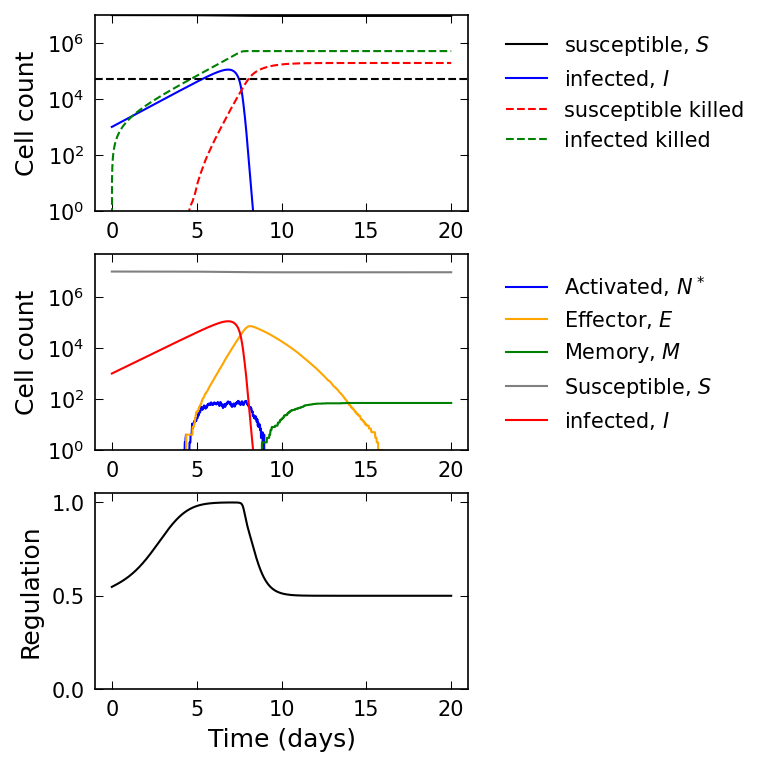

In [7]:
# Plot simulated immune dynamics
fig, (ax1, ax2, ax3) = plt.subplots(3, dpi = 150, constrained_layout=True, sharex = False, figsize=(5,5))

ax1.plot(ts, S, 'k', label = r'susceptible, $S$')
ax1.plot(ts, I, 'b', label = r'infected, $I$')

ax1.plot(ts, I_d_S, 'r', linestyle = '--', label = r'susceptible killed')
ax1.plot(ts, I_d_I, 'g', linestyle = '--', label = r'infected killed')
ax1.axhline(y = K_EH, color = 'k', linestyle = '--')
ax1.set(ylabel='Cell count')
ax1.set_ylim(1,)
ax1.semilogy()
ax1.minorticks_off()
ax1.legend(bbox_to_anchor=(1.05, 1.0), loc='upper left')

ax2.plot(ts, Na, 'b', label = r'Activated, $N^*$')
ax2.plot(ts, E, 'orange', label = r'Effector, $E$')
ax2.plot(ts, M, 'g', label = r'Memory, $M$')
ax2.plot(ts, S, 'grey', label = r'Susceptible, $S$')
ax2.plot(ts, I, 'r', label = r'infected, $I$')
ax2.set(ylabel='Cell count')
ax2.semilogy()
ax2.minorticks_off()
ax2.set_ylim(1, S_0*5)
ax2.legend(bbox_to_anchor=(1.05, 1.0), loc='upper left')

ax3.plot(ts, f_XtoY(sig_1 = I, sig_2 = H, psi_1 = psi_max/2, psi_2 = psi_max/2, psi_1_2 = 0, F_0 = 0.0, K_1 = K_IE, K_2 = K_EH),
         'k-', label = r'Regulation, $f(I,H)$')
ax3.set(xlabel=r'Time (days)', ylabel='Regulation')
ax3.minorticks_off()
ax3.set_ylim(0,1.05)

fig.savefig("_figs/"+infection_type+'-'+'virus-effector dynamics-'+reg_string+'.png', dpi=150, bbox_inches="tight")

5.885966666666667

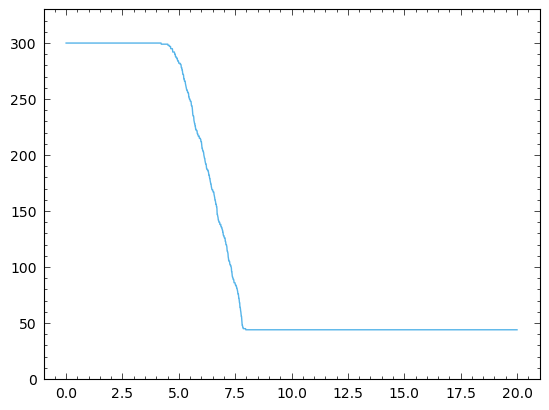

In [8]:
plt.plot(ts, N)
plt.ylim(0, 1.1*N_0)
np.mean(np.argmax(Eff >0 , axis = 0)*(ts[1]-ts[0])*(np.amax(Eff, axis = 0) > 0 ))

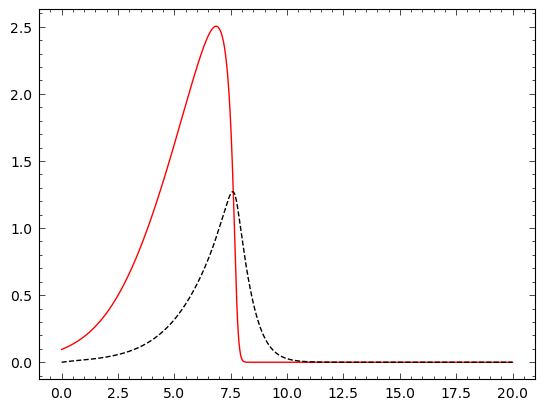

In [9]:
plt.plot(ts, np.log((1 + I/K_IE)), 'r')
plt.plot(ts, np.log((1 + H/K_EH)), 'k--')

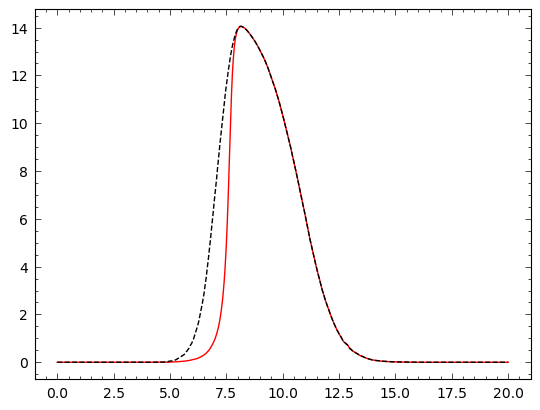

In [10]:
plt.plot(ts,d_IE*E/(K_IE + I + E), 'r')
plt.plot(ts, d_IE*E/(K_IE + E), 'k--')

In [11]:
print(f'Memory fraction = {(np.max(M))/np.max(E)}')
print(f'Number of memory cells = {np.max(M)}')
print(f'1st infection harm = {sim_summary[3]/(d_S*S_0)}')
print(f'1st response toxicity = {sim_summary[4]/(d_S*S_0)}')
print(f'Minimum susceptible = {np.min(S)/S_0}')

Memory fraction = 0.0009674788882285462
Number of memory cells = 70.0
1st infection harm = 5.161602882972754
1st response toxicity = 1.9361443758889751
Minimum susceptible = 0.9327425361130605


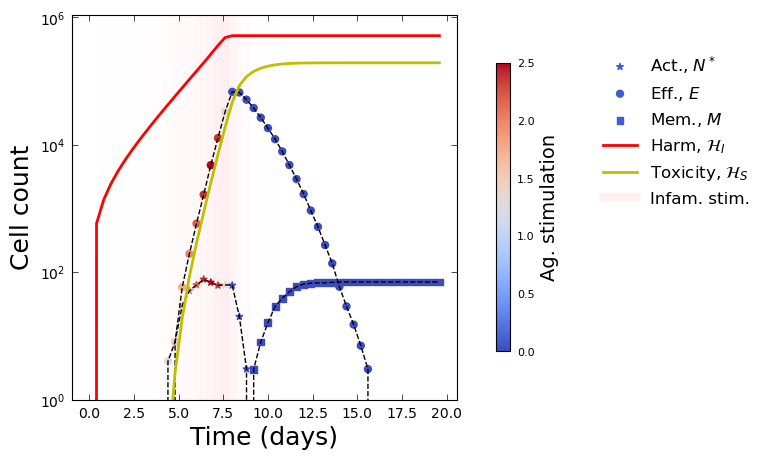

In [12]:
# Plot simulated infection dynamics: pretty plots
pnts = 50
keep = [i*int(len(E)/pnts) for i in np.arange(0,pnts)]
sus = S[keep]
naive = Na[keep]
eff = E[keep]
mem = M[keep]
p_load = np.log(1 + I[keep]/K_IE)
inflam = np.log((1 + H[keep]/K_EH))/np.log((1 + S_0/K_EH))
inf_harm = I_d_I[keep]
toxicity = I_d_S[keep]
time = ts[keep]

fig, ax = plt.subplots(figsize=(10.0,5))

ax.plot(time, naive, 'k--')
im = ax.scatter(time, naive, marker ='*', c = p_load, cmap='coolwarm', 
            label = r'Act., $N^*$') #, norm=mpl.colors.LogNorm())

ax.plot(time, eff, 'k--')
ax.scatter(time, eff, marker ='o', c = p_load, cmap='coolwarm', 
            label = r'Eff., $E$') #, norm=mpl.colors.LogNorm())

ax.plot(time, mem, 'k--')
ax.scatter(time, mem, marker ='s', c = p_load, cmap='coolwarm',
            label = r'Mem., $M$') #, norm=mpl.colors.LogNorm())

ax.plot(time, inf_harm, 'r', linewidth = 2.0, label = r'Harm, $\mathcal{H}_I$')

ax.plot(time, toxicity, 'y', linewidth = 2.0,label = r'Toxicity, $\mathcal{H}_S$')

ax.set_box_aspect(1)
cb = fig.colorbar(im, ax=ax, orientation='vertical', shrink = 0.75, pad = 0.05)
cb.set_label('Ag. stimulation', fontsize = 14)
cb.ax.tick_params(labelsize=8)
ax.set_ylabel('Cell count', fontsize = 18)
ax.set_xlabel(r"Time (days)", fontsize = 18)
ax.semilogy()
ax.minorticks_off()
ax.set_ylim(1,)
locmaj = mpl.ticker.LogLocator(numticks=4)
ax.yaxis.set_major_locator(locmaj)

for i in np.arange(0, len(inflam), 1):
    if i == np.argmax(inflam):
        ax.axvline(x=time[i], linestyle='-', linewidth=5.5, color='pink', alpha=inflam[i], label =r"Infam. stim.", zorder = 0)
    else:
        ax.axvline(x=time[i], linestyle='-', linewidth=5.5, color='pink', alpha=inflam[i], zorder = 0)

ax.legend(loc='center right', bbox_to_anchor=(1.8, 0.7), fontsize = 12)

plt.savefig('_figs/'+infection_type+'-timeline-of-infection-dynamics-'+reg_string+'.png', dpi=150, bbox_inches="tight")

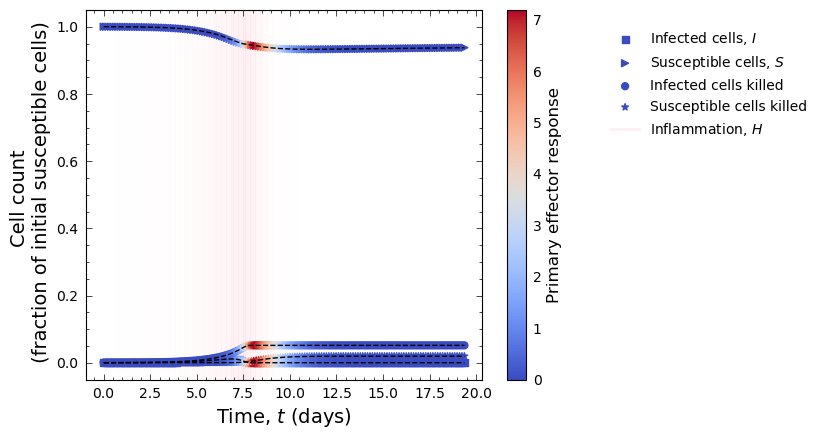

In [13]:
# Plot simulated infection dynamics: pretty plots of harm
pnts = 150
keep = [i*int(len(E)/pnts) for i in np.arange(0,pnts)]

eff = E[keep]
p_load = I[keep]/S_0
sus = S[keep]/S_0
inf_harm = I_d_I[keep]/S_0
inflam_harm = I_d_S[keep]/S_0
inflam = np.log((1 + H[keep]/K_EH))/np.log((1 + S_0/K_EH))
time = ts[keep]

plt.scatter(time, p_load, marker ='s', c =eff/K_IE, cmap='coolwarm', 
            label = r'Infected cells, $I$') #, norm=mpl.colors.LogNorm())
plt.plot(time, p_load, 'k--')

plt.scatter(time, sus, marker ='>', c =eff/K_IE, cmap='coolwarm', 
            label = r'Susceptible cells, $S$') #, norm=mpl.colors.LogNorm())
plt.plot(time, sus, 'k--')

plt.scatter(time, inf_harm, marker ='o', c =eff/K_IE, cmap='coolwarm', 
            label = 'Infected cells killed')
plt.plot(time, inf_harm, 'k--')

plt.scatter(time, inflam_harm, marker ='*', c =eff/K_IE, cmap='coolwarm',
            label = 'Susceptible cells killed')
plt.plot(time, inflam_harm, 'k--')

plt.colorbar(label = "Primary effector response")
plt.ylabel('Cell count \n (fraction of initial susceptible cells)', fontsize = 14)
plt.xlabel(r"Time, $t$ (days)", fontsize = 14)

for i in np.arange(0, len(inflam), 1):
    if i == np.argmax(inflam):
        plt.axvline(x=time[i], linestyle='-', linewidth=2.0, color='pink', alpha=inflam[i], label =r"Inflammation, $H$", zorder = 0)
    else:
        plt.axvline(x=time[i], linestyle='-', linewidth=2.0, color='pink', alpha=inflam[i], zorder = 0)
        
plt.legend(loc='center right', bbox_to_anchor=(1.85, 0.8), fontsize = 10)
plt.savefig('_figs/'+infection_type+'-infection-harm-'+reg_string+'.png', dpi=150, bbox_inches="tight")

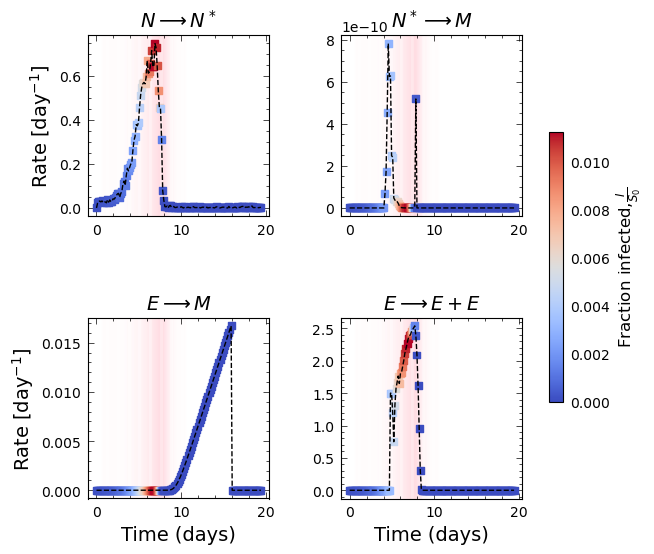

In [14]:
# Plot simulated infection dynamics: pretty plots
pnts = 150
keep = [1 + i*int(len(E)/pnts) for i in np.arange(0,pnts)]
bias_diff = p_diff[keep] if infection_type == "prim" else s_diff[keep]
p_load = I[keep]/S_0
sus = S[keep]
inflam =  np.log((1 + H[keep]/K_EH))/np.log((1 + S_0/K_EH))
time = ts[keep]

fig, axs = plt.subplots(2,2, figsize=(7,7))

for i in np.arange(0, len(inflam), 1):
    if i == np.argmax(inflam):
        axs[0,0].axvline(x=time[i], linestyle='-', linewidth=2.0, color='pink', alpha=inflam[i], zorder = 0)
        axs[0,1].axvline(x=time[i], linestyle='-', linewidth=2.0, color='pink', alpha=inflam[i], zorder = 0)
        axs[1,0].axvline(x=time[i], linestyle='-', linewidth=2.0, color='pink', alpha=inflam[i], zorder = 0)
        axs[1,1].axvline(x=time[i], linestyle='-', linewidth=2.0, color='pink', alpha=inflam[i], zorder = 0, label =r"Inflammation, $H$")
    else:
        axs[0,0].axvline(x=time[i], linestyle='-', linewidth=2.0, color='pink', alpha=inflam[i], zorder = 0)
        axs[0,1].axvline(x=time[i], linestyle='-', linewidth=2.0, color='pink', alpha=inflam[i], zorder = 0)
        axs[1,0].axvline(x=time[i], linestyle='-', linewidth=2.0, color='pink', alpha=inflam[i], zorder = 0)
        axs[1,1].axvline(x=time[i], linestyle='-', linewidth=2.0, color='pink', alpha=inflam[i], zorder = 0, label =r"Inflammation, $H$")

im1 = axs[0,0].scatter(time, bias_diff[:,0], marker = 's', c =p_load, cmap='coolwarm', 
            label = r'$N \longrightarrow N^*$')
axs[0,0].plot(time, bias_diff[:,0],'k--')
axs[0,0].title.set_text(r'$N \longrightarrow N^*$')
axs[0,0].set_box_aspect(1)

im2 = axs[0,1].scatter(time, bias_diff[:,1], marker = 's', c =p_load, cmap='coolwarm', 
            label = r'$N^* \longrightarrow M$')
axs[0,1].plot(time, bias_diff[:,1],'k--')
axs[0,1].title.set_text(r'$N^* \longrightarrow M$')
axs[0,1].set_box_aspect(1)

im3 = axs[1,0].scatter(time, bias_diff[:,2], marker = 's', c =p_load, cmap='coolwarm', 
            label = r'$E \longrightarrow M$')
axs[1,0].plot(time, bias_diff[:,2],'k--')
axs[1,0].title.set_text(r'$E \longrightarrow M$')
axs[1,0].set_box_aspect(1)

im4 = axs[1,1].scatter(time, bias_diff[:,3], marker = 's', c =p_load, cmap='coolwarm', 
            label = r'$E \longrightarrow M$')
axs[1,1].plot(time, bias_diff[:,3],'k--')
axs[1,1].title.set_text(r'$E \longrightarrow E + E$')
axs[1,1].set_box_aspect(1)

axs[0,0].set_ylabel('Rate [day$^{-1}$]', fontsize = 14)
axs[1,0].set_ylabel('Rate [day$^{-1}$]', fontsize = 14)
axs[1,0].set_xlabel("Time (days)", fontsize = 14)
axs[1,1].set_xlabel("Time (days)", fontsize = 14)

fig.subplots_adjust(wspace=.4, hspace = 0.1)
cb = fig.colorbar(im1, ax=axs, shrink = 0.5, pad = 0.05, orientation='vertical')
cb.set_label('Fraction infected,'+ r'$\frac{I}{S_0}$')

#cb.set_clim(-0.4,0.4)
    
# plt.colorbar(label =r"pathogen load, $I(t)$")
# plt.ylabel('transition weight', fontsize = 16)
# plt.xlabel("time (days)", fontsize = 16)
# plt.legend() #bbox_to_anchor=(1.05, 1.0), loc='upper left')

plt.savefig('_figs/'+infection_type+'-diff-bias-over-time-'+reg_string+'.png', dpi=150, bbox_inches="tight")

### (2) Plot lineage-based trajectories

/tmp/ipykernel_68769/3021603312.py:6: RuntimeWarning: invalid value encountered in divide
  norm_counts = all_counts / total_counts[:, None]


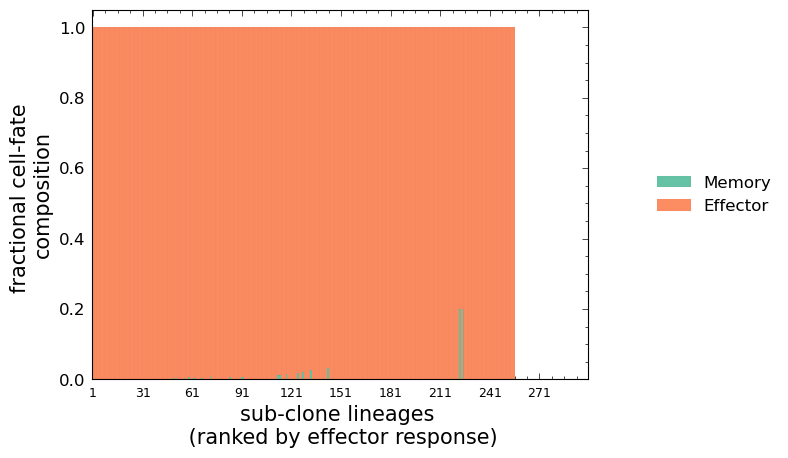

In [15]:
keys = np.array(['Memory', 'Effector'])
all_counts = lin_comp[1:3].T
effector_ranking = np.argsort(all_counts[:, 1])[::-1]
all_counts = all_counts[effector_ranking]
total_counts = all_counts.sum(axis=1)
norm_counts = all_counts / total_counts[:, None]
norm_counts[~np.isfinite(norm_counts)] = 0
comp_argsort = np.argsort(np.max(all_counts, axis=0))
bar_dict = {k: v for k, v in zip(keys[comp_argsort], norm_counts.T[comp_argsort])}
lineage_idxs = np.arange(all_counts.shape[0])

fig, ax = plt.subplots()
bottom = np.zeros(len(lineage_idxs))
cmap_colors = sns.color_palette('Set2', 10)
cmap_colors = [cmap_colors[i]
               for i in [0, 1, 5]]#[7, 2, 0, 1, 5]]
# cmap_colors = [cmap_colors[i]
#                for i in [6, 1, 2, 5, 0]]
width = 1

for i, (celltype, fraction) in enumerate(bar_dict.items()):
    ax.bar(lineage_idxs, fraction, width,
           edgecolor='k', linewidth=0.01,
           label=celltype, bottom=bottom, color=cmap_colors[i])
    bottom += fraction
    
ax.legend(loc='center right', bbox_to_anchor=(1.4, 0.5), fontsize = 12)
ax.set_xlim(-0.5, len(all_counts) - 0.5)
ax.set_xlabel('sub-clone lineages \n (ranked by effector response)', fontsize = 15)
ax.set_ylabel('fractional cell-fate \ncomposition', fontsize = 15)
#ax.set_yscale('log')

ax.set_xticks(np.arange(0, Eff.shape[1], int(Eff.shape[1]/10)))
ax.set_xticklabels(1 + np.arange(0, Eff.shape[1], int(Eff.shape[1]/10)), fontsize=9)

ax.set_yticks(np.round(np.arange(0, 1.2, 0.2), 1))
ax.set_yticklabels(ax.get_yticks(), fontsize=12)

fig.savefig("_figs/"+infection_type+'-'+'fates-by-lin-'+reg_string+'.png', dpi=150, bbox_inches="tight")


[]

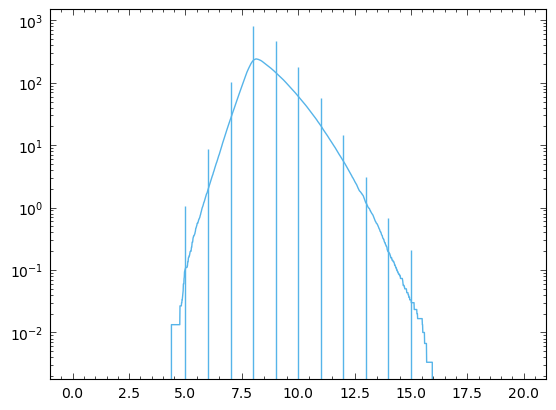

In [16]:
plt.errorbar(ts, np.mean(Eff, axis = 1), yerr = np.std(Eff, axis = 1), errorevery = 100)
plt.semilogy()

0.15


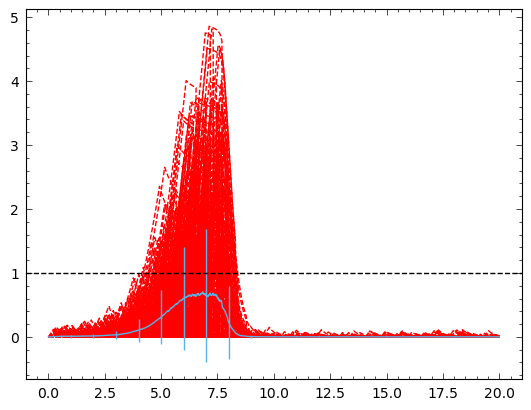

In [17]:
plt.plot(ts, mycN, 'r--')
plt.errorbar(ts, np.mean(mycN, axis = 1), yerr = np.std(mycN, axis = 1), errorevery = 100)
#plt.plot(ts, mycMa, 'k-')
plt.axhline(y = myc_thresh, color = 'k', linestyle = '--')
print(np.sum(np.max(mycE, axis=0) < myc_thresh)/N_0)

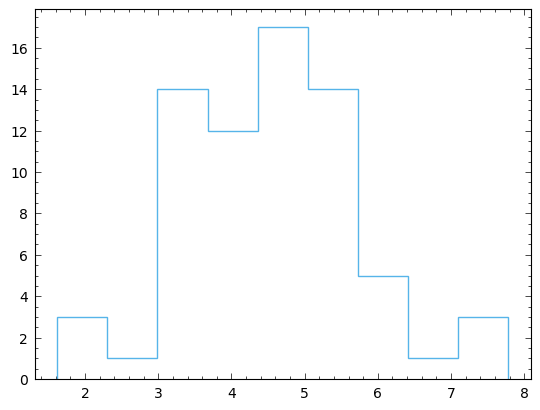

In [18]:
#plt.hist(np.argmax(mycNa > 0, axis = 0)*sim_duration/sim_steps, bins='auto')
plt.hist(T_pEcytM, bins='auto', histtype='step');
# plt.hist(T_sEcytM, bins='auto', histtype='step');

Text(0.5, 0.98, 'Peak response response: $N_0=$ 300, $d_I=$1.25')

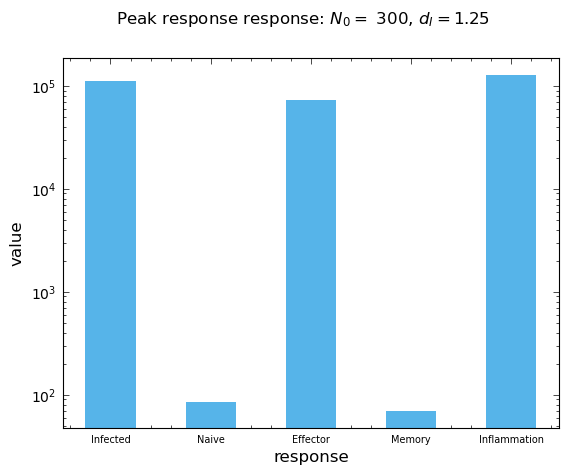

In [19]:
# Compute max values in the data
r = np.arange(5)
width = 0.5
plt.bar(r, np.amax(np.array([I, Na, E, M, H]).T, axis = 0), width = width)

plt.xlabel("response")
plt.ylabel("value")

plt.xticks(r, ["Infected","Naive","Effector","Memory", "Inflammation"], fontsize = 7)

plt.semilogy()
plt.suptitle(r'Peak response response: $N_0=$ '+str(N_0) +r', $d_I=$'+str(d_I))

In [20]:
bias_1 = f_XtoY(I, H, 
       -2.0, -2.0, 0.0, F_0 = 4*np.log(2), 
       K_I = K_IE, K_H = K_EH)
bias_2 = f_XtoY(I, H, 
       -2.0, 2.0, 0.0, F_0 = -0*np.log(2), 
       K_I = K_IE, K_H = K_EH)

plt.plot(ts, bias_1, 'r')
plt.plot(ts, bias_2, 'k--')
plt.plot(ts, Na/np.amax(Na))
plt.plot(ts, A/(Na + A))
plt.plot(ts, H**l_H/(K_EH**l_H + H**l_H))

TypeError: f_XtoY() got an unexpected keyword argument 'K_I'

In [ ]:
d="/gscratch/scrubbed/oukogu/infoimmune/sim_output/no_cell_var/raw/"
comment = "Nact-Ediv-vir"
runs = 1

run(batch = [652.0], outdir=d, comment=comment, runs = runs, num_cpu = 40)

In [ ]:
d_file = '/gscratch/scrubbed/oukogu/infoimmune/sim_output/no_cell_var/raw/sim_batch_0-'+str(runs)+'-prim-'+comment+'.pkl'
with open(d_file, 'rb') as f:   
    out = pickle.load(f)